In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train_data.csv
/kaggle/input/titanic/test_data.csv


In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline
df=pd.read_csv('/kaggle/input/titanic/train_data.csv')
df.head()

,Unnamed: 0,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,0,1,0,1,0.2750,0.014151,0,0,1,0.1,1,0,0,0,0,0,1
1,1,2,1,0,0.4750,0.139136,1,0,0,0.1,1,0,0,0,1,0,0
2,2,3,1,0,0.3250,0.015469,0,0,1,0.0,0,0,0,1,0,0,1
3,3,4,1,0,0.4375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1
4,4,5,0,1,0.4375,0.015713,0,0,1,0.0,1,0,0,0,0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   792 non-null    int64  
 1   PassengerId  792 non-null    int64  
 2   Survived     792 non-null    int64  
 3   Sex          792 non-null    int64  
 4   Age          792 non-null    float64
 5   Fare         792 non-null    float64
 6   Pclass_1     792 non-null    int64  
 7   Pclass_2     792 non-null    int64  
 8   Pclass_3     792 non-null    int64  
 9   Family_size  792 non-null    float64
 10  Title_1      792 non-null    int64  
 11  Title_2      792 non-null    int64  
 12  Title_3      792 non-null    int64  
 13  Title_4      792 non-null    int64  
 14  Emb_1        792 non-null    int64  
 15  Emb_2        792 non-null    int64  
 16  Emb_3        792 non-null    int64  
dtypes: float64(3), int64(14)
memory usage: 105.3 KB


In [4]:
df.duplicated().sum()

0

# data is clean
## but the 'age' and 'family size' should be fixed

In [5]:
df['Age']=round(df['Age']*100).astype(int)
df['Age'].head()

0    28
1    48
2    32
3    44
4    44
Name: Age, dtype: int64

In [6]:
df['Family_size']=round(df['Family_size']*10).astype(int)
df['Family_size'].head()

0    1
1    1
2    0
3    1
4    0
Name: Family_size, dtype: int64

# reggrision

In [7]:
df['intercept']=1
x= df[['intercept','Age','Sex','Pclass_1','Pclass_2','Pclass_3']]
y= df['Survived']

In [8]:
logit_model=sm.Logit(y,x)
resualts=logit_model.fit()
resualts.summary()

Optimization terminated successfully.
         Current function value: 0.452798
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  792
Model:                          Logit   Df Residuals:                      786
Method:                           MLE   Df Model:                            5
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.3212
Time:                        19:45:56   Log-Likelihood:                -358.62
converged:                       True   LL-Null:                       -528.34
Covariance Type:            nonrobust   LLR p-value:                 3.277e-71
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.7631   5.43e+06   3.25e-07      1.000   -1.06e+07    1.06e+07
Age           -0.0248      0.006     -3.996      0.000      -0.037      -0.013
Sex           -2.6422      0.199    -13.293      0.000      -3.032      -2.253
Pclass_1       1.6874   5.43e+06   3.11e-07      1.000   -1.06e+07    1.06e+07
Pclass_2       0.6521   5.43e+06    1.2e-07      1.000   -1.06e+07    1.06e+07
Pclass_3      -0.5765   5.43e+06  -1.06e-07      1.000   -1.06e+07    1.06e+07
==============================================================================
"""

In [9]:
np.exp(1.1866),1/np.exp(-0.0248),1/np.exp(-2.6422),np.exp(2.2639),np.exp(1.2286)

(3.2759241090931117,
 1.0251100780052593,
 14.044066592505805,
 9.62053618874353,
 3.4164431661797185)

- we find that age decrease by 1 the survival rate increases by 1.02
- we find that sex decrease by 1 the survival rate increases by 14.04
- we find that p class_1 increaeses by 1 the survival rate increases by 9.62
- we find that p class_2 increaeses by 1 the survival rate increases by 3.41


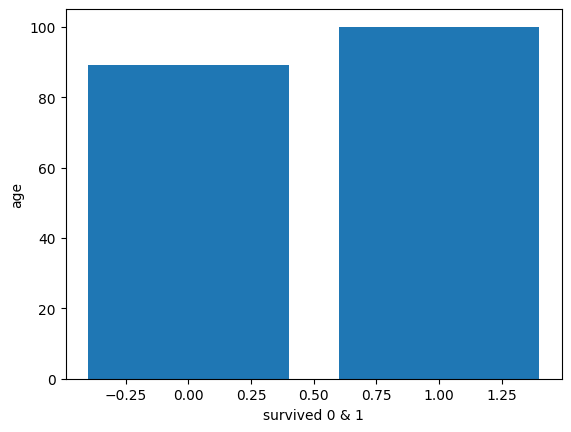

In [10]:
plt.bar(df['Survived'],df['Age'])
plt.xlabel('survived 0 & 1')
plt.ylabel('age')
plt.show()

Text(0, 0.5, 'sex')

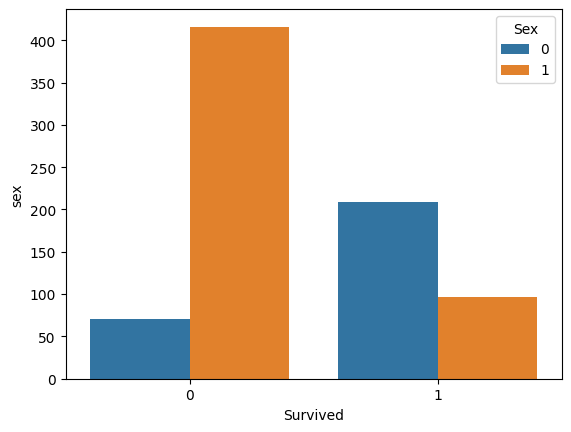

In [11]:
sns.countplot(x=df['Survived'],hue=df['Sex'])
plt.ylabel('sex')

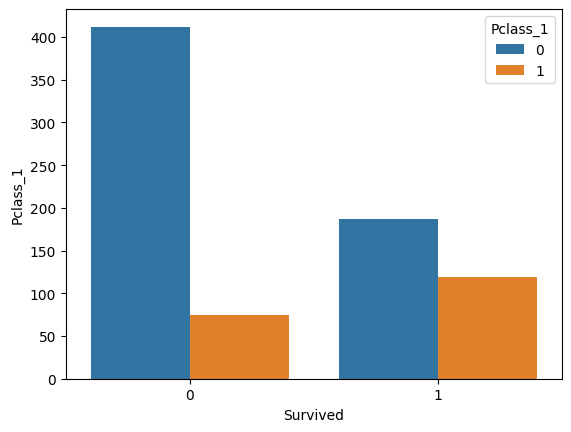

In [12]:
sns.countplot(x=df['Survived'],hue=df['Pclass_1'])
plt.ylabel('Pclass_1')
plt.show()